# ✈️ Airline Passenger Satisfaction Prediction

## 06. ANN Model Optimization

This notebook systematically improves the Artificial Neural Network developed in the previous stage.

The optimization process includes:

- Loading the processed datasets
- Loading the baseline ANN
- Establishing baseline performance
- Testing alternative ANN architectures
- Testing different learning rates
- Testing different batch sizes
- Using regularization
- Comparing validation performance
- Selecting the best configuration
- Evaluating the optimized model on the unseen test dataset
- Comparing baseline and optimized performance
- Saving the optimized model and configuration

In [1]:
# Step 2 : Importing Libraries

import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Step 3 : Setting Random Seeds

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
# Step 4 : Loading Processed Data

X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (83123, 27)
Validation: (20781, 27)
Testing: (25976, 27)


In [4]:
# Step 5 : Defining Input Features

input_features = X_train.shape[1]

print("ANN Input Features:", input_features)

ANN Input Features: 27


In [5]:
# Step 6 : Loading Baseline ANN

baseline_model_path = "../models/best_airline_satisfaction_ann.keras"

baseline_model = tf.keras.models.load_model(
    baseline_model_path
)

print("Baseline ANN loaded successfully.")

Baseline ANN loaded successfully.


In [6]:
# Step 7 : Generating Baseline Predictions

baseline_probability = baseline_model.predict(
    X_test,
    verbose=0
).ravel()

baseline_prediction = (
    baseline_probability >= 0.50
).astype(int)

print("Baseline predictions generated.")

Baseline predictions generated.


In [7]:
# Step 8 : Calculating Baseline Metrics

baseline_accuracy = accuracy_score(
    y_test,
    baseline_prediction
)

baseline_precision = precision_score(
    y_test,
    baseline_prediction
)

baseline_recall = recall_score(
    y_test,
    baseline_prediction
)

baseline_f1 = f1_score(
    y_test,
    baseline_prediction
)

baseline_roc_auc = roc_auc_score(
    y_test,
    baseline_probability
)

baseline_pr_auc = average_precision_score(
    y_test,
    baseline_probability
)

baseline_metrics = {
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1,
    "ROC-AUC": baseline_roc_auc,
    "PR-AUC": baseline_pr_auc
}

pd.DataFrame(
    [baseline_metrics]
).round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,0.9636,0.9717,0.9447,0.958,0.9949,0.9941


In [8]:
# Step 9 : Creating a Reusable ANN Builder

def build_ann(
    hidden_layers,
    dropout_rates,
    learning_rate
):
    
    model = Sequential()
    
    for i, neurons in enumerate(hidden_layers):
        
        if i == 0:
            model.add(
                Dense(
                    neurons,
                    activation="relu",
                    input_shape=(input_features,)
                )
            )
        else:
            model.add(
                Dense(
                    neurons,
                    activation="relu"
                )
            )
        
        if dropout_rates[i] > 0:
            model.add(
                Dropout(dropout_rates[i])
            )
    
    model.add(
        Dense(
            1,
            activation="sigmoid"
        )
    )
    
    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [9]:
# Step 10 : Creating the Training Function

def train_candidate_model(
    hidden_layers,
    dropout_rates,
    learning_rate,
    batch_size,
    epochs=40
):
    
    model = build_ann(
        hidden_layers=hidden_layers,
        dropout_rates=dropout_rates,
        learning_rate=learning_rate
    )
    
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.00001,
        verbose=0
    )
    
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[
            early_stopping,
            reduce_lr
        ],
        shuffle=True,
        verbose=0
    )
    
    return model, history

In [10]:
# Step 11 : Defining Optimization Experiments

experiments = [
    
    {
        "name": "Baseline Architecture",
        "hidden_layers": [64, 32, 16],
        "dropout_rates": [0.30, 0.20, 0.00],
        "learning_rate": 0.001,
        "batch_size": 32
    },
    
    {
        "name": "Larger Architecture",
        "hidden_layers": [128, 64, 32],
        "dropout_rates": [0.30, 0.20, 0.00],
        "learning_rate": 0.001,
        "batch_size": 32
    },
    
    {
        "name": "Stronger Regularization",
        "hidden_layers": [64, 32, 16],
        "dropout_rates": [0.40, 0.30, 0.00],
        "learning_rate": 0.001,
        "batch_size": 32
    },
    
    {
        "name": "Lower Learning Rate",
        "hidden_layers": [64, 32, 16],
        "dropout_rates": [0.30, 0.20, 0.00],
        "learning_rate": 0.0005,
        "batch_size": 32
    },
    
    {
        "name": "Smaller Batch Size",
        "hidden_layers": [64, 32, 16],
        "dropout_rates": [0.30, 0.20, 0.00],
        "learning_rate": 0.001,
        "batch_size": 16
    }
]

print("Number of experiments:", len(experiments))

for experiment in experiments:
    print("\n", experiment["name"])
    print(experiment)

Number of experiments: 5

 Baseline Architecture
{'name': 'Baseline Architecture', 'hidden_layers': [64, 32, 16], 'dropout_rates': [0.3, 0.2, 0.0], 'learning_rate': 0.001, 'batch_size': 32}

 Larger Architecture
{'name': 'Larger Architecture', 'hidden_layers': [128, 64, 32], 'dropout_rates': [0.3, 0.2, 0.0], 'learning_rate': 0.001, 'batch_size': 32}

 Stronger Regularization
{'name': 'Stronger Regularization', 'hidden_layers': [64, 32, 16], 'dropout_rates': [0.4, 0.3, 0.0], 'learning_rate': 0.001, 'batch_size': 32}

 Lower Learning Rate
{'name': 'Lower Learning Rate', 'hidden_layers': [64, 32, 16], 'dropout_rates': [0.3, 0.2, 0.0], 'learning_rate': 0.0005, 'batch_size': 32}

 Smaller Batch Size
{'name': 'Smaller Batch Size', 'hidden_layers': [64, 32, 16], 'dropout_rates': [0.3, 0.2, 0.0], 'learning_rate': 0.001, 'batch_size': 16}


In [11]:
# Step 12 : Training Candidate Models

experiment_results = []
trained_models = {}
training_histories = {}

for experiment in experiments:
    
    print(
        f"\nTraining: {experiment['name']}"
    )
    
    model, history = train_candidate_model(
        hidden_layers=experiment["hidden_layers"],
        dropout_rates=experiment["dropout_rates"],
        learning_rate=experiment["learning_rate"],
        batch_size=experiment["batch_size"]
    )
    
    validation_probability = model.predict(
        X_val,
        verbose=0
    ).ravel()
    
    validation_prediction = (
        validation_probability >= 0.50
    ).astype(int)
    
    val_accuracy = accuracy_score(
        y_val,
        validation_prediction
    )
    
    val_precision = precision_score(
        y_val,
        validation_prediction
    )
    
    val_recall = recall_score(
        y_val,
        validation_prediction
    )
    
    val_f1 = f1_score(
        y_val,
        validation_prediction
    )
    
    val_roc_auc = roc_auc_score(
        y_val,
        validation_probability
    )
    
    val_pr_auc = average_precision_score(
        y_val,
        validation_probability
    )
    
    experiment_results.append({
        "Experiment": experiment["name"],
        "Architecture": str(experiment["hidden_layers"]),
        "Dropout": str(experiment["dropout_rates"]),
        "Learning Rate": experiment["learning_rate"],
        "Batch Size": experiment["batch_size"],
        "Epochs Trained": len(history.history["loss"]),
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1,
        "Validation ROC-AUC": val_roc_auc,
        "Validation PR-AUC": val_pr_auc
    })
    
    trained_models[
        experiment["name"]
    ] = model
    
    training_histories[
        experiment["name"]
    ] = history
    
    print(
        f"Validation F1: {val_f1:.4f} | "
        f"ROC-AUC: {val_roc_auc:.4f}"
    )


Training: Baseline Architecture


c:\Users\dhanu\Desktop\airline-ann\.myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation F1: 0.9562 | ROC-AUC: 0.9950

Training: Larger Architecture


c:\Users\dhanu\Desktop\airline-ann\.myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation F1: 0.9581 | ROC-AUC: 0.9954

Training: Stronger Regularization


...

Validation F1: 0.9542 | ROC-AUC: 0.9945

Training: Lower Learning Rate


c:\Users\dhanu\Desktop\airline-ann\.myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation F1: 0.9564 | ROC-AUC: 0.9948

Training: Smaller Batch Size


c:\Users\dhanu\Desktop\airline-ann\.myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation F1: 0.9577 | ROC-AUC: 0.9950


In [12]:
# Step 13 : Comparing Optimization Experiments

optimization_results = pd.DataFrame(
    experiment_results
)

optimization_results = optimization_results.sort_values(
    by="Validation F1",
    ascending=False
).reset_index(drop=True)

optimization_results.round(4)

,Experiment,Architecture,Dropout,Learning Rate,Batch Size,Epochs Trained,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC,Validation PR-AUC
0,Larger Architecture,"[128, 64, 32]","[0.3, 0.2, 0.0]",0.0010,32,33,0.9641,0.9700,0.9465,0.9581,0.9954,0.9945
1,Smaller Batch Size,"[64, 32, 16]","[0.3, 0.2, 0.0]",0.0010,16,40,0.9638,0.9691,0.9466,0.9577,0.9950,0.9941
2,Lower Learning Rate,"[64, 32, 16]","[0.3, 0.2, 0.0]",0.0005,32,40,0.9628,0.9704,0.9428,0.9564,0.9948,0.9939
3,Baseline Architecture,"[64, 32, 16]","[0.3, 0.2, 0.0]",0.0010,32,38,0.9625,0.9687,0.9440,0.9562,0.9950,0.9941
4,Stronger Regularization,"[64, 32, 16]","[0.4, 0.3, 0.0]",0.0010,32,40,0.9608,0.9668,0.9419,0.9542,0.9945,0.9935


In [13]:
# Step 14 : Identifying the Best Configuration

best_experiment_name = optimization_results.loc[
    0,
    "Experiment"
]

best_experiment = next(
    experiment
    for experiment in experiments
    if experiment["name"] == best_experiment_name
)

print("Best Experiment:")
print(best_experiment_name)

print("\nConfiguration:")
print(best_experiment)

Best Experiment:
Larger Architecture

Configuration:
{'name': 'Larger Architecture', 'hidden_layers': [128, 64, 32], 'dropout_rates': [0.3, 0.2, 0.0], 'learning_rate': 0.001, 'batch_size': 32}


In [14]:
# Step 15 : Displaying Best Validation Metrics

best_result = optimization_results.iloc[0]

print("Best Configuration:", best_result["Experiment"])
print("Validation Accuracy:", round(best_result["Validation Accuracy"], 4))
print("Validation Precision:", round(best_result["Validation Precision"], 4))
print("Validation Recall:", round(best_result["Validation Recall"], 4))
print("Validation F1:", round(best_result["Validation F1"], 4))
print("Validation ROC-AUC:", round(best_result["Validation ROC-AUC"], 4))
print("Validation PR-AUC:", round(best_result["Validation PR-AUC"], 4))

Best Configuration: Larger Architecture
Validation Accuracy: 0.9641
Validation Precision: 0.97
Validation Recall: 0.9465
Validation F1: 0.9581
Validation ROC-AUC: 0.9954
Validation PR-AUC: 0.9945


In [15]:
# Step 16 : Retrieving the Best Model

optimized_model = trained_models[
    best_experiment_name
]

print("Best optimized ANN retrieved successfully.")

Best optimized ANN retrieved successfully.


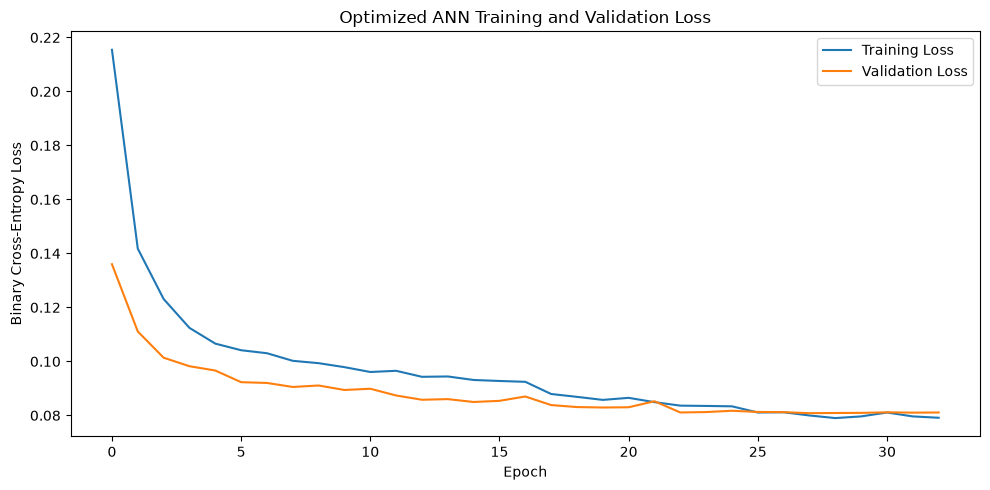

In [16]:
# Step 17 : Plotting Best Model Training History

best_history = training_histories[
    best_experiment_name
]

plt.figure(figsize=(10, 5))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Optimized ANN Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()

plt.tight_layout()
plt.show()

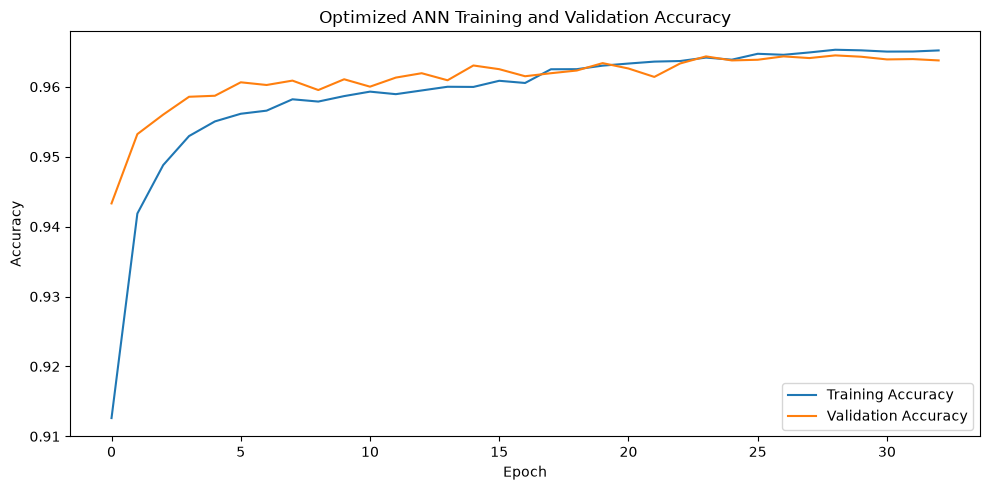

In [17]:
# Step 18 : Plotting Optimized Accuracy

plt.figure(figsize=(10, 5))

plt.plot(
    best_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    best_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Optimized ANN Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# Step 19 : Generating Optimized Test Predictions

optimized_probability = optimized_model.predict(
    X_test,
    verbose=0
).ravel()

optimized_prediction = (
    optimized_probability >= 0.50
).astype(int)

print("Optimized test predictions generated.")

Optimized test predictions generated.


In [19]:
# Step 20 : Calculating Optimized Test Metrics

optimized_accuracy = accuracy_score(
    y_test,
    optimized_prediction
)

optimized_precision = precision_score(
    y_test,
    optimized_prediction
)

optimized_recall = recall_score(
    y_test,
    optimized_prediction
)

optimized_f1 = f1_score(
    y_test,
    optimized_prediction
)

optimized_roc_auc = roc_auc_score(
    y_test,
    optimized_probability
)

optimized_pr_auc = average_precision_score(
    y_test,
    optimized_probability
)

optimized_metrics = {
    "Accuracy": optimized_accuracy,
    "Precision": optimized_precision,
    "Recall": optimized_recall,
    "F1-Score": optimized_f1,
    "ROC-AUC": optimized_roc_auc,
    "PR-AUC": optimized_pr_auc
}

pd.DataFrame(
    [optimized_metrics]
).round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,0.9641,0.9717,0.9458,0.9586,0.9952,0.9944


In [20]:
# Step 21 : Comparing Baseline and Optimized Models

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Baseline ANN": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc,
        baseline_pr_auc
    ],
    "Optimized ANN": [
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1,
        optimized_roc_auc,
        optimized_pr_auc
    ]
})

comparison_df["Improvement"] = (
    comparison_df["Optimized ANN"]
    - comparison_df["Baseline ANN"]
)

comparison_df.round(4)

,Metric,Baseline ANN,Optimized ANN,Improvement
0,Accuracy,0.9636,0.9641,0.0005
1,Precision,0.9717,0.9717,0.0000
2,Recall,0.9447,0.9458,0.0011
3,F1-Score,0.9580,0.9586,0.0006
4,ROC-AUC,0.9949,0.9952,0.0003
5,PR-AUC,0.9941,0.9944,0.0003


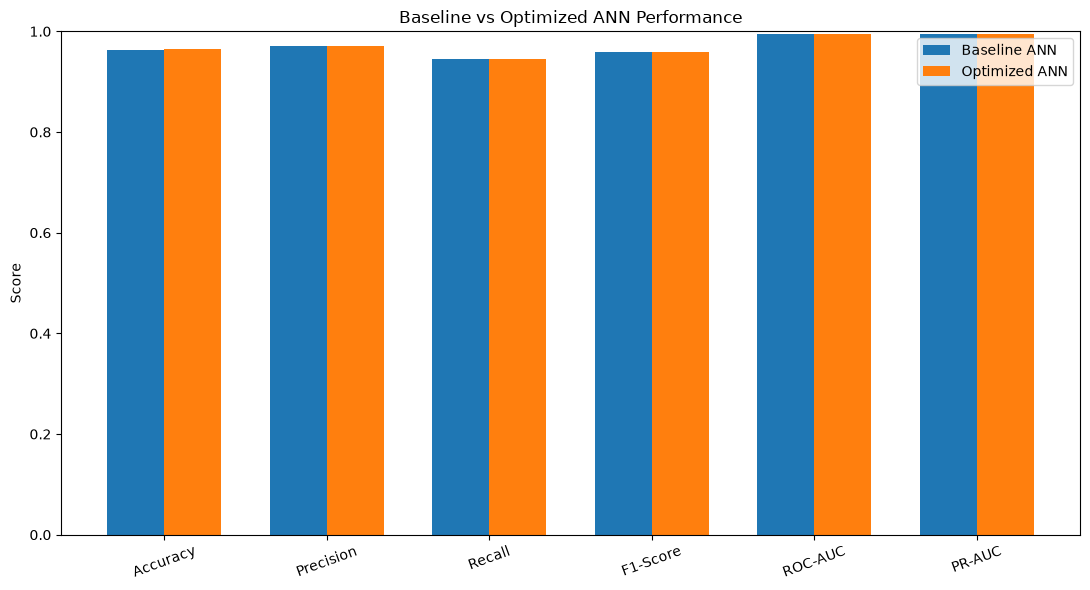

In [21]:
# Step 22 : Plotting Baseline vs Optimized Performance

plot_df = comparison_df.copy()

x = np.arange(
    len(plot_df["Metric"])
)

width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    plot_df["Baseline ANN"],
    width,
    label="Baseline ANN"
)

plt.bar(
    x + width / 2,
    plot_df["Optimized ANN"],
    width,
    label="Optimized ANN"
)

plt.xticks(
    x,
    plot_df["Metric"],
    rotation=20
)

plt.ylabel("Score")
plt.title("Baseline vs Optimized ANN Performance")
plt.ylim(0, 1)

plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# Step 23 : Calculating Optimization Improvement

f1_improvement = (
    optimized_f1 - baseline_f1
)

roc_auc_improvement = (
    optimized_roc_auc - baseline_roc_auc
)

accuracy_improvement = (
    optimized_accuracy - baseline_accuracy
)

print(
    "Accuracy Improvement:",
    round(accuracy_improvement, 4)
)

print(
    "F1-Score Improvement:",
    round(f1_improvement, 4)
)

print(
    "ROC-AUC Improvement:",
    round(roc_auc_improvement, 4)
)

Accuracy Improvement: 0.0005
F1-Score Improvement: 0.0006
ROC-AUC Improvement: 0.0003


In [23]:
# Step 24 : Generating Optimized Confusion Matrix

optimized_cm = confusion_matrix(
    y_test,
    optimized_prediction
)

print("Optimized Confusion Matrix:")
print(optimized_cm)

Optimized Confusion Matrix:
[[14259   314]
 [  618 10785]]


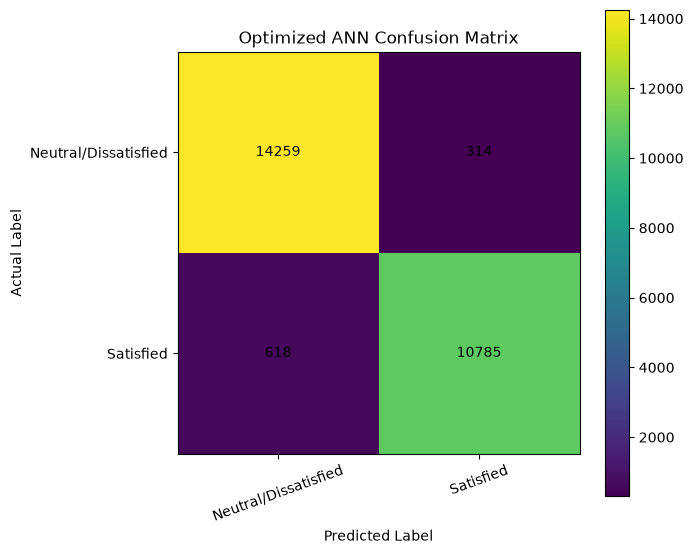

In [24]:
# Step 25 : Visualizing Optimized Confusion Matrix

plt.figure(figsize=(7, 6))

plt.imshow(
    optimized_cm,
    interpolation="nearest"
)

plt.title("Optimized ANN Confusion Matrix")
plt.colorbar()

plt.xticks(
    [0, 1],
    ["Neutral/Dissatisfied", "Satisfied"],
    rotation=20
)

plt.yticks(
    [0, 1],
    ["Neutral/Dissatisfied", "Satisfied"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            optimized_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [25]:
# Step 26 : Creating Optimization Folder

optimization_folder = "../models/optimization"

os.makedirs(
    optimization_folder,
    exist_ok=True
)

print("Optimization folder is ready.")

Optimization folder is ready.


In [26]:
# Step 27 : Saving Optimized Model

optimized_model_path = (
    "../models/optimization/"
    "optimized_airline_satisfaction_ann.keras"
)

optimized_model.save(
    optimized_model_path
)

print("Optimized model saved to:")
print(optimized_model_path)

Optimized model saved to:
../models/optimization/optimized_airline_satisfaction_ann.keras


In [27]:
# Step 28 : Saving Optimization Results

optimization_results.to_csv(
    "../models/optimization/"
    "optimization_experiments.csv",
    index=False
)

comparison_df.to_csv(
    "../models/optimization/"
    "baseline_vs_optimized.csv",
    index=False
)

print("Optimization results saved successfully.")

Optimization results saved successfully.


In [28]:
# Step 29 : Saving Optimized Configuration

optimized_config = {
    "experiment_name": best_experiment_name,
    "hidden_layers": best_experiment["hidden_layers"],
    "dropout_rates": best_experiment["dropout_rates"],
    "learning_rate": best_experiment["learning_rate"],
    "batch_size": best_experiment["batch_size"],
    "input_features": int(input_features),
    "activation_hidden": "relu",
    "activation_output": "sigmoid",
    "loss": "binary_crossentropy",
    "optimizer": "Adam",
    "seed": SEED
}

with open(
    "../models/optimization/"
    "optimized_model_config.json",
    "w"
) as file:
    
    json.dump(
        optimized_config,
        file,
        indent=4
    )

print("Optimized configuration saved successfully.")

Optimized configuration saved successfully.


In [29]:
# Step 30 : Creating Final Optimization Summary

print("=" * 65)
print("FINAL ANN OPTIMIZATION SUMMARY")
print("=" * 65)

print("\nBaseline ANN Performance")
print("-" * 40)
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1-Score :", round(baseline_f1, 4))
print("ROC-AUC  :", round(baseline_roc_auc, 4))
print("PR-AUC   :", round(baseline_pr_auc, 4))

print("\nOptimized ANN Performance")
print("-" * 40)
print("Accuracy :", round(optimized_accuracy, 4))
print("Precision:", round(optimized_precision, 4))
print("Recall   :", round(optimized_recall, 4))
print("F1-Score :", round(optimized_f1, 4))
print("ROC-AUC  :", round(optimized_roc_auc, 4))
print("PR-AUC   :", round(optimized_pr_auc, 4))

print("\nSelected Configuration")
print("-" * 40)
print("Experiment:", best_experiment_name)
print("Hidden Layers:", best_experiment["hidden_layers"])
print("Dropout Rates:", best_experiment["dropout_rates"])
print("Learning Rate:", best_experiment["learning_rate"])
print("Batch Size:", best_experiment["batch_size"])

print("\nOptimization completed successfully.")

FINAL ANN OPTIMIZATION SUMMARY

Baseline ANN Performance
----------------------------------------
Accuracy : 0.9636
Precision: 0.9717
Recall   : 0.9447
F1-Score : 0.958
ROC-AUC  : 0.9949
PR-AUC   : 0.9941

Optimized ANN Performance
----------------------------------------
Accuracy : 0.9641
Precision: 0.9717
Recall   : 0.9458
F1-Score : 0.9586
ROC-AUC  : 0.9952
PR-AUC   : 0.9944

Selected Configuration
----------------------------------------
Experiment: Larger Architecture
Hidden Layers: [128, 64, 32]
Dropout Rates: [0.3, 0.2, 0.0]
Learning Rate: 0.001
Batch Size: 32

Optimization completed successfully.


# ✅ ANN Optimization Conclusion

The baseline Artificial Neural Network was systematically compared with multiple candidate configurations.

The optimization process evaluated changes in:

- Network architecture
- Number of neurons
- Dropout regularization
- Learning rate
- Batch size

Each candidate was trained using the same training and validation datasets, while the provided test dataset was kept separate until final evaluation.

The configuration with the strongest validation F1-score was selected as the optimized ANN.

The optimized model was then evaluated on the unseen test dataset and compared against the baseline ANN using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

The optimized ANN and all optimization results have been saved for the final application and project documentation.

In [30]:
# Step 32 : Verifying Optimization Files

optimization_files = [
    "optimized_airline_satisfaction_ann.keras",
    "optimization_experiments.csv",
    "baseline_vs_optimized.csv",
    "optimized_model_config.json"
]

for file_name in optimization_files:

    file_path = os.path.join(
        optimization_folder,
        file_name
    )

    print(
        f"{file_name}:",
        "Exists" if os.path.exists(file_path)
        else "Missing"
    )

optimized_airline_satisfaction_ann.keras: Exists
optimization_experiments.csv: Exists
baseline_vs_optimized.csv: Exists
optimized_model_config.json: Exists
